In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [3]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

df_country = pd.read_csv("../Data/country_ai_index.csv")

In [4]:
# I want to merge country to company for the correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [ ]:
#Gathering business success parameters for correlation 
success_factors = df_company[
    [
        # Success measures
        "ai_maturity_score",
        "productivity_change_percent",
        "ai_failure_rate",
        "revenue_growth_percent",
        "customer_satisfaction",

        # Possible drivers
        "years_using_ai",
        "ai_training_hours",
        "ai_budget_percentage",
        "num_ai_tools_used",
        "ai_investment_per_employee",
        "regulatory_compliance_score",
        "ai_risk_management_score"
    ]
]

In [10]:
business_success = df_company[
    [
        # outcomes
        "productivity_change_percent",
        "cost_reduction_percent",
        "revenue_growth_percent",
        "innovation_score",
        "customer_satisfaction",
        "employee_satisfaction_score",

        # possible drivers
        "ai_adoption_rate",
        "ai_maturity_score",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_investment_per_employee",
        "num_ai_tools_used",
        "ai_projects_active",
        "ai_risk_management_score"
    ]
]

business_corr = business_success.corr()

In [6]:
success_corr = success_factors.corr()

success_corr

,ai_maturity_score,productivity_change_percent,ai_failure_rate,revenue_growth_percent,customer_satisfaction,years_using_ai,ai_training_hours,ai_budget_percentage,num_ai_tools_used,ai_investment_per_employee,regulatory_compliance_score,ai_risk_management_score
ai_maturity_score,1.000000,0.737314,-0.697749,0.403190,0.458789,0.155064,0.821696,0.819248,0.454016,0.297108,0.010925,0.445840
productivity_change_percent,0.737314,1.000000,-0.593667,0.476247,0.569821,0.116494,0.633740,0.604105,0.364423,0.218707,0.010039,0.328775
ai_failure_rate,-0.697749,-0.593667,1.000000,-0.322041,-0.434765,-0.098316,-0.739570,-0.527048,-0.351571,-0.194754,-0.003887,-0.312925
revenue_growth_percent,0.403190,0.476247,-0.322041,1.000000,0.277019,0.072800,0.347841,0.340629,0.216696,0.121861,0.009992,0.180570
customer_satisfaction,0.458789,0.569821,-0.434765,0.277019,1.000000,0.068908,0.415638,0.368443,0.226932,0.132962,0.007297,0.204855
years_using_ai,0.155064,0.116494,-0.098316,0.072800,0.068908,1.000000,0.134539,0.138527,0.118055,0.043809,0.005332,0.065638
ai_training_hours,0.821696,0.633740,-0.739570,0.347841,0.415638,0.134539,1.000000,0.560236,0.393811,0.204215,0.008030,0.365538
ai_budget_percentage,0.819248,0.604105,-0.527048,0.340629,0.368443,0.138527,0.560236,1.000000,0.400556,0.350236,0.010780,0.367073
num_ai_tools_used,0.454016,0.364423,-0.351571,0.216696,0.226932,0.118055,0.393811,0.400556,1.000000,0.143924,0.006523,0.201708
ai_investment_per_employee,0.297108,0.218707,-0.194754,0.121861,0.132962,0.043809,0.204215,0.350236,0.143924,1.000000,0.001123,0.136389


The next few cells will isolate correlation results

In [7]:
success_corr["ai_maturity_score"].sort_values(
    ascending=False
)

ai_maturity_score              1.000000
ai_training_hours              0.821696
ai_budget_percentage           0.819248
productivity_change_percent    0.737314
customer_satisfaction          0.458789
num_ai_tools_used              0.454016
ai_risk_management_score       0.445840
revenue_growth_percent         0.403190
ai_investment_per_employee     0.297108
years_using_ai                 0.155064
regulatory_compliance_score    0.010925
ai_failure_rate               -0.697749
Name: ai_maturity_score, dtype: float64

In [8]:
success_corr["productivity_change_percent"].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
revenue_growth_percent         0.476247
num_ai_tools_used              0.364423
ai_risk_management_score       0.328775
ai_investment_per_employee     0.218707
years_using_ai                 0.116494
regulatory_compliance_score    0.010039
ai_failure_rate               -0.593667
Name: productivity_change_percent, dtype: float64

In [12]:
# What correlates with productivity
business_corr[
    "productivity_change_percent"
].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_adoption_rate               0.674973
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
ai_projects_active             0.566833
revenue_growth_percent         0.476247
innovation_score               0.405074
num_ai_tools_used              0.364423
cost_reduction_percent         0.345855
ai_risk_management_score       0.328775
employee_satisfaction_score    0.290436
ai_investment_per_employee     0.218707
Name: productivity_change_percent, dtype: float64

In [13]:
# What correlates with cost reduction
business_corr[
    "cost_reduction_percent"
].sort_values(
    ascending=False
)

cost_reduction_percent         1.000000
ai_adoption_rate               0.404302
ai_maturity_score              0.386162
productivity_change_percent    0.345855
ai_budget_percentage           0.328713
ai_training_hours              0.328314
ai_projects_active             0.289453
innovation_score               0.222638
num_ai_tools_used              0.218866
customer_satisfaction          0.205888
revenue_growth_percent         0.190982
ai_risk_management_score       0.171646
employee_satisfaction_score    0.147959
ai_investment_per_employee     0.117579
Name: cost_reduction_percent, dtype: float64

In [14]:
# What correlates with innovation?
business_corr[
    "innovation_score"
].sort_values(
    ascending=False
)

innovation_score               1.000000
ai_maturity_score              0.531790
ai_adoption_rate               0.509864
ai_budget_percentage           0.445472
ai_training_hours              0.444496
ai_projects_active             0.412083
productivity_change_percent    0.405074
num_ai_tools_used              0.274924
customer_satisfaction          0.248808
ai_risk_management_score       0.236262
revenue_growth_percent         0.230596
cost_reduction_percent         0.222638
employee_satisfaction_score    0.203174
ai_investment_per_employee     0.161687
Name: innovation_score, dtype: float64

In [15]:
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

business_outcomes

,productivity_change_percent,revenue_growth_percent,cost_reduction_percent
ai_adoption_stage,,,
full,19.792315,10.491941,8.588315
none,2.391995,0.500773,2.188411
partial,12.026603,6.149891,5.770517
pilot,6.165857,2.893164,3.757529


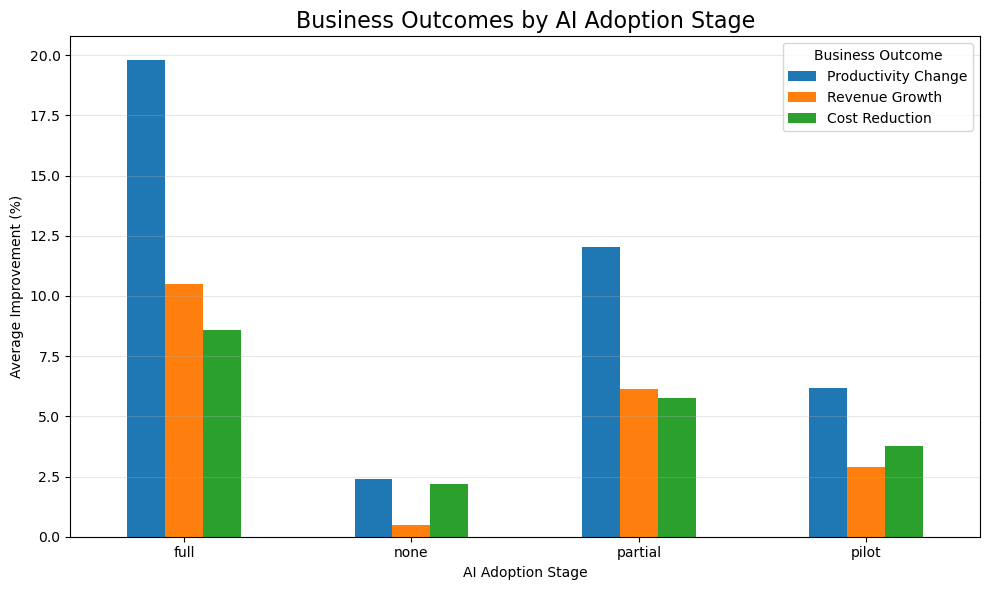

In [16]:
import matplotlib.pyplot as plt

business_outcomes.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Business Outcomes by AI Adoption Stage",
    fontsize=16
)

plt.xlabel(
    "AI Adoption Stage"
)

plt.ylabel(
    "Average Improvement (%)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    [
        "Productivity Change",
        "Revenue Growth",
        "Cost Reduction"
    ],
    title="Business Outcome"
)

plt.grid(
    axis="y",
    alpha=.3
)

plt.tight_layout()

plt.show()

The next set of cells will set the stage for 

In [17]:
df_company["maturity_group"] = pd.cut(
    df_company["ai_maturity_score"],
    bins=[0,.25,.5,.75,1],
    labels=[
        "Low",
        "Developing",
        "Advanced",
        "High"
    ]
)

In [18]:
maturity_business = (
    df_company
    .groupby("maturity_group")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

C:\Users\patri\AppData\Local\Temp\ipykernel_37044\346655041.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("maturity_group")


In [19]:
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

business_outcomes

,productivity_change_percent,revenue_growth_percent,cost_reduction_percent
ai_adoption_stage,,,
full,19.792315,10.491941,8.588315
none,2.391995,0.500773,2.188411
partial,12.026603,6.149891,5.770517
pilot,6.165857,2.893164,3.757529


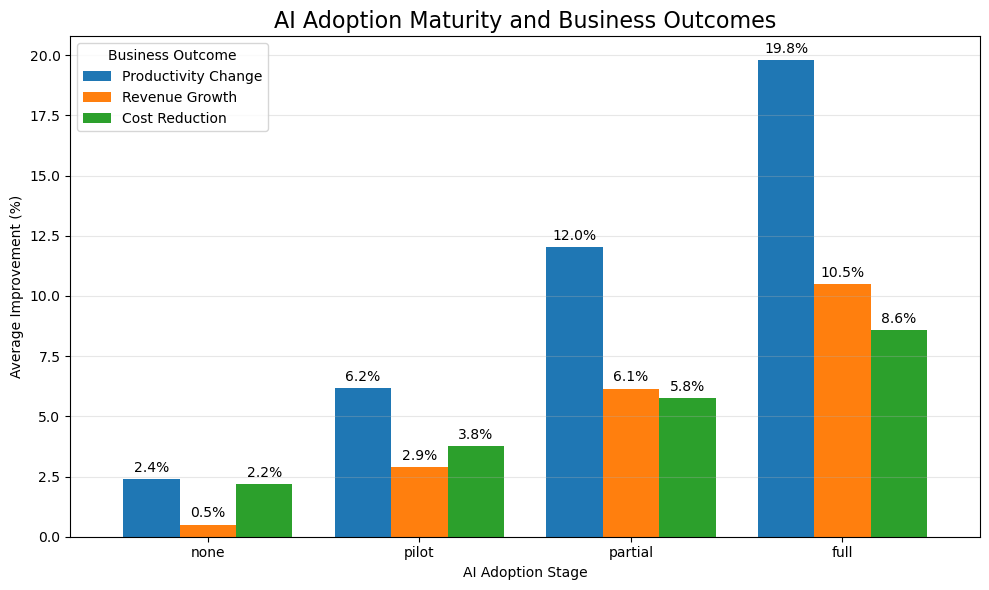

In [ ]:
import matplotlib.pyplot as plt

# Calculate average business outcomes by adoption stage
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)


# Reorder adoption stages logically
stage_order = [
    "none",
    "pilot",
    "partial",
    "full"]

business_outcomes = business_outcomes.loc[stage_order]


# Create grouped bar chart
ax = business_outcomes.plot(
    kind="bar",
    figsize=(10,6),
    width=.8
)


# Add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )


# Chart formatting
plt.title(
    "AI Adoption Maturity and Business Outcomes",
    fontsize=16)

plt.xlabel(
    "AI Adoption Stage")

plt.ylabel(
    "Average Improvement (%)")

plt.xticks(
    rotation=0)
plt.legend(
    [
        "Productivity Change",
        "Revenue Growth",
        "Cost Reduction"
    ],
    title="Business Outcome")
plt.grid(
    axis="y",
    alpha=.3)
plt.tight_layout()
plt.savefig(
    "../Images/business_outcomes_ai_adoption.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

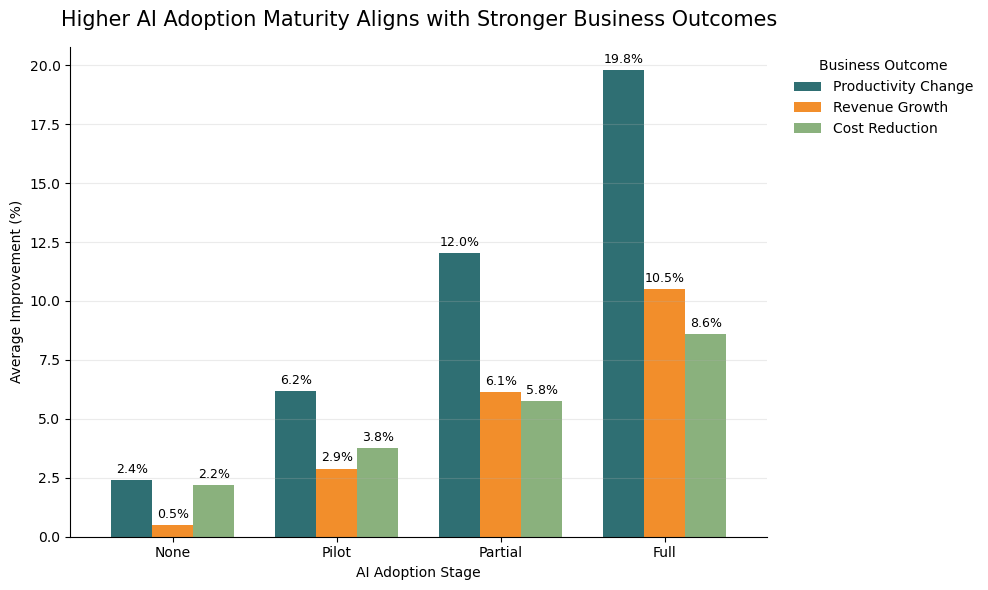

In [21]:
import matplotlib.pyplot as plt

# Reorder adoption stages
stage_order = ["none", "pilot", "partial", "full"]

business_outcomes = business_outcomes.loc[stage_order]

# Rename columns for cleaner legend
business_outcomes_clean = business_outcomes.rename(
    columns={
        "productivity_change_percent": "Productivity Change",
        "revenue_growth_percent": "Revenue Growth",
        "cost_reduction_percent": "Cost Reduction"
    }
)

# Colors to match your deck
colors = ["#2F6F73", "#F28E2B", "#8AB17D"]

fig, ax = plt.subplots(figsize=(10, 6))

business_outcomes_clean.plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.75
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.set_title(
    "Higher AI Adoption Maturity Aligns with Stronger Business Outcomes",
    fontsize=15,
    pad=15
)

ax.set_xlabel("AI Adoption Stage")
ax.set_ylabel("Average Improvement (%)")

ax.set_xticklabels(
    ["None", "Pilot", "Partial", "Full"],
    rotation=0
)

ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Business Outcome",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "business_outcomes_by_ai_stage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

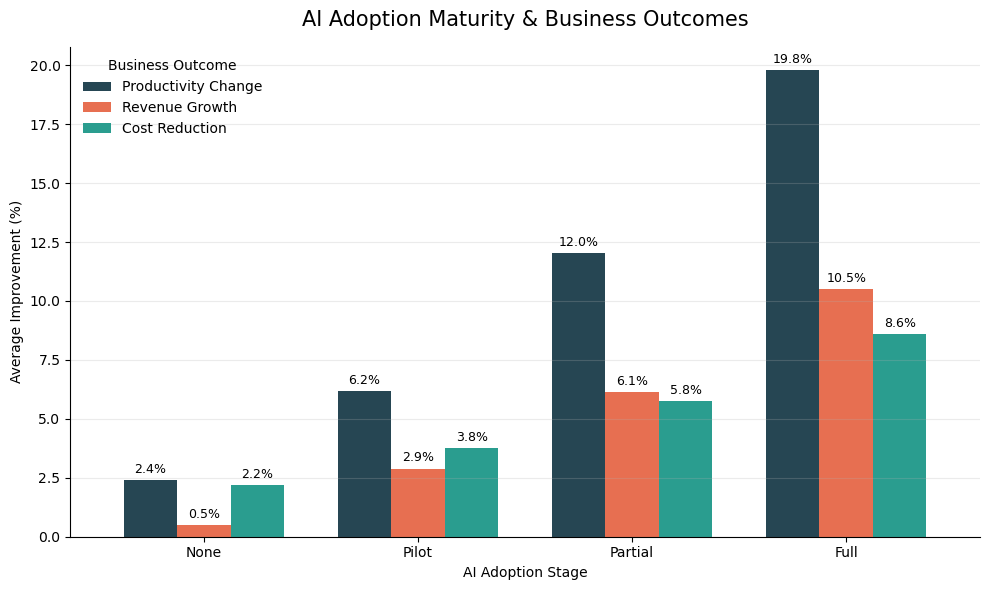

In [25]:
import matplotlib.pyplot as plt


# Order adoption maturity stages
stage_order = [
    "none",
    "pilot",
    "partial",
    "full"
]

business_outcomes = business_outcomes.loc[stage_order]


# Rename columns for cleaner labels
business_outcomes_clean = business_outcomes.rename(
    columns={
        "productivity_change_percent": "Productivity Change",
        "revenue_growth_percent": "Revenue Growth",
        "cost_reduction_percent": "Cost Reduction"
    }
)


# Colorblind-friendly palette (Okabe-Ito inspired)
colors = [
    "#264653",   # dark blue-teal
    "#E76F51",   # coral orange
    "#2A9D8F"    # green teal
]


# Create figure
fig, ax = plt.subplots(
    figsize=(10, 6)
)


# Plot grouped bar chart
business_outcomes_clean.plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.75
)


# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )


# Title and labels
ax.set_title(
    "AI Adoption Maturity & Business Outcomes",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "AI Adoption Stage"
)

ax.set_ylabel(
    "Average Improvement (%)"
)


# Clean x-axis labels
ax.set_xticklabels(
    [
        "None",
        "Pilot",
        "Partial",
        "Full"
    ],
    rotation=0
)


# Move legend inside chart
ax.legend(
    title="Business Outcome",
    frameon=False,
    loc="upper left"
)


# Grid formatting
ax.grid(
    axis="y",
    alpha=0.25
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Tight layout
plt.tight_layout()


# Save for presentation
plt.savefig(
    "business_outcomes_by_ai_stage.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()